# Поиск выбросов — простое объяснение

Упрощённая версия практики.  
Разбираем **что такое выбросы**, **зачем их искать** и **как находить** — на маленьких примерах и простыми словами.

## План

1. [Словарь терминов](#dict)
2. [Что такое выброс и откуда он берётся](#what)
3. [Группы методов поиска](#methods)
4. [Статистика: гистограмма, boxplot, IQR, Z-score](#stats)
5. [Модельный подход (на пальцах)](#model)
6. [Метрические идеи: соседи и LOF](#metric)
7. [Методы ML: Isolation Forest, One-Class SVM](#ml)
8. [Кластеризация: DBSCAN](#dbscan)
9. [Мини-практика на sklearn](#practice)
10. [Итог](#итог)



<a id="dict"></a>
## 1. Словарь (обязательно прочитать)

| Термин | Простыми словами |
|--------|------------------|
| **Датасет** | Таблица с данными |
| **Объект / точка / sample** | Одна строка (один человек, одно вино, один день) |
| **Признак / feature** | Столбец (возраст, цена, кислотность…) |
| **Выброс / outlier / anomaly** | Точка, которая **сильно выбивается** из «обычной» картины |
| **Шум** | Случайный «мусор» в данных; иногда похож на выброс |
| **Распределение** | Как часто встречаются разные значения (гистограмма) |
| **Среднее (mean)** | Сумма / количество |
| **Медиана** | Значение «посередине» после сортировки |
| **Стандартное отклонение (std)** | Насколько значения «размазаны» вокруг среднего |
| **Квартиль** | Точки, которые делят отсортированные данные на 4 части |
| **IQR** | Межквартильный размах: «ширина середины» данных |
| **Boxplot (ящик с усами)** | График, на котором удобно видеть типичный разброс и выбросы |
| **Кластер** | Кучка похожих точек |
| **Метрика расстояния** | Как измеряем «далеко / близко» между точками |
| **Модель** | Алгоритм, который учится на данных и что-то предсказывает/оценивает |
| **Обучение (fit)** | «Запомнить закономерность по данным» |
| **Предсказание (predict)** | «Сказать для новой точки: норма / выброс» |
| **Нормальные точки (inliers)** | То, что алгоритм считает обычным |
| **Novelty detection** | Ищем странности, которых **не было** при обучении |



<a id="what"></a>
## 2. Что такое выброс?

**Выброс** — значение (или целая строка), которое **не похоже** на основную массу данных.

### Примеры из жизни
- В таблице возрастов студентов почти все 18–25, а одно значение **120** — подозрительно.
- Зарплаты в компании около 50–100 тыс., а одно **10 000 000** — либо ошибка, либо реально топ-менеджер (нужно понять природу!).
- Сенсор температуры обычно 18–25°C, а вдруг **−200** — скорее поломка датчика.

### Откуда берутся
1. **Ошибка ввода** (человек написал 1000 вместо 100).
2. **Шум / сбой прибора**.
3. **Другая «популяция»** попала в таблицу (смешали два разных набора).
4. **Редкая, но настоящая аномалия** (мошенничество, авария) — это уже не «мусор», а сигнал.

### Почему это важно в ML
Многие модели (линейная регрессия, kNN, нейронки) **чувствительны** к экстремальным числам:  
один выброс может «утащить» среднее, коэффициенты и ухудшить качество.

> Правило: сначала **найти** → потом **понять природу** → только потом удалять / чинить / оставлять.



<a id="methods"></a>
## 3. Какие бывают методы (карта)

| Группа | Идея | Примеры |
|--------|------|---------|
| **Статистические** | «Далеко от типичных чисел» | boxplot, IQR, Z-score |
| **Модельные** | «Модель плохо объясняет точку» | регрессия + большие ошибки |
| **Итерационные** | «Снимаем оболочку снова и снова» | выпуклые оболочки (реже в быту) |
| **Метрические** | «Точка далеко от соседей» | kNN-расстояния, LOF, DBSCAN |
| **Методы ML** | «Алгоритм сам учит, что странно» | Isolation Forest, One-Class SVM |

Дальше — **сначала руками на 10 числах**, потом готовые алгоритмы sklearn.



<a id="stats"></a>
## 4. Статистические методы

Самый понятный старт: смотрим на **один признак**.



In [117]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

# чтобы графики были стабильнее при повторном запуске
np.random.seed(42)



### 4.1. Маленький пример «рост учеников»

Почти все 150–180 см, но есть **ошибка 250** и **ошибка 50**.



In [118]:
# «Обычные» роста + два явных выброса
heights = np.array([160, 165, 170, 172, 168, 175, 158, 162, 171, 169, 250, 50])

df_h = pd.DataFrame({"height_cm": heights})
df_h



,height_cm
0,160
1,165
2,170
3,172
4,168
5,175
6,158
7,162
8,171
9,169


### 4.2. Гистограмма

Показывает, **куда** «падают» значения. Выбросы часто сидят **отдельно** от основной кучи.



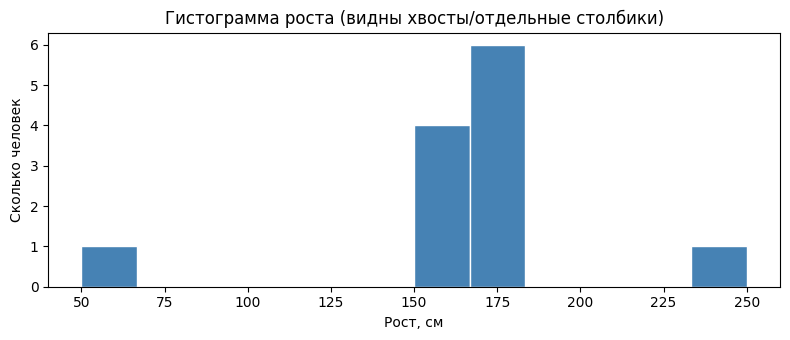

In [119]:
plt.figure(figsize=(8, 3.5))
plt.hist(df_h["height_cm"], bins=12, edgecolor="white", color="steelblue")
plt.xlabel("Рост, см")
plt.ylabel("Сколько человек")
plt.title("Гистограмма роста (видны хвосты/отдельные столбики)")
plt.tight_layout()
plt.show()



### 4.3. Boxplot («ящик с усами»)

- **Ящик** — середина данных (между 25% и 75% — это **IQR**).
- **Усы** — типичный разброс.
- Точки **за усами** — кандидаты в **выбросы**.



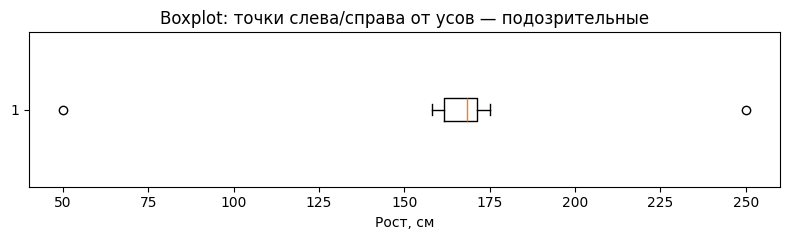

In [120]:
plt.figure(figsize=(8, 2.5))
plt.boxplot(df_h["height_cm"], vert=False)
plt.xlabel("Рост, см")
plt.title("Boxplot: точки слева/справа от усов — подозрительные")
plt.tight_layout()
plt.show()



### 4.4. Правило IQR (классика boxplot)

1. Считаем **Q1** (25-й процентиль) и **Q3** (75-й).
2. **IQR = Q3 − Q1** (ширина «ящика»).
3. Всё, что **ниже** `Q1 − 1.5·IQR` или **выше** `Q3 + 1.5·IQR`, часто считают выбросом.

Число **1.5** — договорённость (можно 3 для более «жёстких» только экстремумов).



In [121]:
q1 = df_h["height_cm"].quantile(0.25)
q3 = df_h["height_cm"].quantile(0.75)
iqr = q3 - q1

low = q1 - 1.5 * iqr
high = q3 + 1.5 * iqr

print("Q1 =", q1)
print("Q3 =", q3)
print("IQR =", iqr)
print("Нижняя граница =", low)
print("Верхняя граница =", high)

df_h["is_outlier_iqr"] = (
    (df_h["height_cm"] < low) | (df_h["height_cm"] > high)
).astype(int)

df_h



Q1 = 161.5
Q3 = 171.25
IQR = 9.75
Нижняя граница = 146.875
Верхняя граница = 185.875


,height_cm,is_outlier_iqr
0,160,0
1,165,0
2,170,0
3,172,0
4,168,0
5,175,0
6,158,0
7,162,0
8,171,0
9,169,0


### 4.5. Z-score: «на сколько std от среднего»

$$
z = \frac{x - \text{mean}}{\text{std}}
$$

Если **|z| > 3** (иногда 2 или 2.5), точку часто считают выбросом.

Минус: среднее и std **сами** портятся от выбросов.  
Поэтому иногда берут **модифицированный Z** на медиане — но для старта хватит обычного.



In [122]:
mean_h = df_h["height_cm"].mean()
std_h = df_h["height_cm"].std(ddof=0)  # ddof=0 — деление на n (как «по всей выборке»)

df_h["zscore"] = (df_h["height_cm"] - mean_h) / std_h
df_h["is_outlier_z"] = (df_h["zscore"].abs() > 2).astype(int)  # порог 2 — нагляднее на малой выборке

print("mean =", round(mean_h, 2), "std =", round(std_h, 2))
df_h



mean = 164.17 std = 41.59


,height_cm,is_outlier_iqr,zscore,is_outlier_z
0,160,0,-0.100177,0
1,165,0,0.020035,0
2,170,0,0.140248,0
3,172,0,0.188333,0
4,168,0,0.092163,0
5,175,0,0.260461,0
6,158,0,-0.148262,0
7,162,0,-0.052092,0
8,171,0,0.164291,0
9,169,0,0.116206,0


### Вывод по статистике
- Быстро, понятно, хорошо для **одного** столбца.
- Плохо, если выброс «нормальный по каждому признаку отдельно», но **странный в комбинации** (нужны многомерные методы ниже).



<a id="model"></a>
## 5. Модельный подход (идея)

Предположим: «сумма кредита ≈ зависит от дохода».

Строим простую линию.  
Точки с **огромной ошибкой** (далеко от линии) — кандидаты в выбросы.

Это **модельный тест**: выброс = то, что модель **не может объяснить**.



In [123]:
from sklearn.linear_model import LinearRegression

# синтетика: доход -> «ожидаемая» сумма + 2 странные точки
income = np.array([30, 40, 50, 60, 70, 80, 90, 100, 55, 65], dtype=float)
loan = 2 * income + 10 + np.random.normal(0, 5, size=income.shape)
# два выброса
loan[0] = 400   # при маленьком доходе огромный кредит
loan[-1] = 20   # при большом доходе крошечный кредит

X = income.reshape(-1, 1)
reg = LinearRegression().fit(X, loan)
pred = reg.predict(X)
err = np.abs(loan - pred)

df_m = pd.DataFrame({
    "income": income,
    "loan": loan,
    "pred": pred.round(1),
    "abs_error": err.round(1),
})
# выброс по ошибке: например, топ-2 самых больших ошибок
threshold = np.sort(err)[-2]
df_m["is_outlier_model"] = (err >= threshold - 1e-9).astype(int)
df_m



,income,loan,pred,abs_error,is_outlier_model
0,30.0,400.000000,180.4,219.6,1
1,40.0,89.308678,174.6,85.3,0
2,50.0,113.238443,168.8,55.6,0
3,60.0,137.615149,163.0,25.4,0
4,70.0,148.829233,157.3,8.4,0
5,80.0,168.829315,151.5,17.4,0
6,90.0,197.896064,145.7,52.2,0
7,100.0,213.837174,139.9,73.9,0
8,55.0,117.652628,165.9,48.3,0
9,65.0,20.000000,160.1,140.1,1


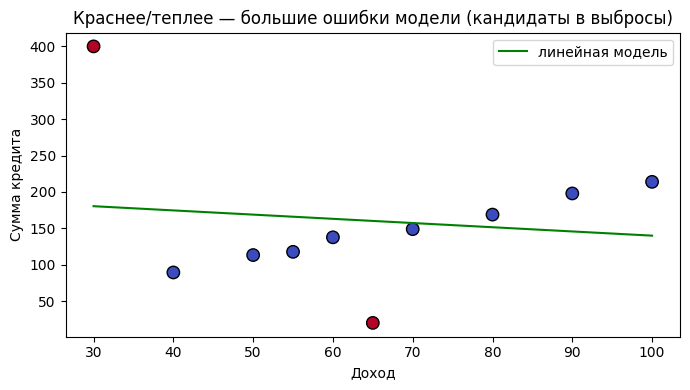

In [124]:
plt.figure(figsize=(7, 4))
plt.scatter(income, loan, c=df_m["is_outlier_model"], cmap="coolwarm", s=80, edgecolors="k")
# линия модели
xs = np.linspace(income.min(), income.max(), 50)
plt.plot(xs, reg.predict(xs.reshape(-1, 1)), "g-", label="линейная модель")
plt.xlabel("Доход")
plt.ylabel("Сумма кредита")
plt.title("Краснее/теплее — большие ошибки модели (кандидаты в выбросы)")
plt.legend()
plt.tight_layout()
plt.show()



<a id="metric"></a>
## 6. Метрические методы: «смотри на соседей»

Идея: **нормальные** точки живут в **плотных кучках**.  
**Выброс** — один в «чистом поле».

### 6.1. kNN-мысль
Смотрим среднее расстояние до **k ближайших соседей**.  
Если расстояние огромное — точка одинокая → выброс.

### 6.2. LOF (Local Outlier Factor)
Сравнивает **плотность** точки с плотностью соседей.

- LOF ≈ 1 — «как соседи»  
- LOF ≫ 1 — «разреженнее соседей» → похоже на выброс  

`LocalOutlierFactor` в sklearn: `predict` даёт **1** (норма) или **-1** (выброс).



[[-0.32339744 -0.20070282]
 [ 0.36616085  0.13150044]
 [-0.21190408  0.20530697]
 [ 3.5         3.        ]
 [-3.          2.5       ]
 [ 2.8        -3.2       ]]
[0.94770591 1.16191737 1.20412902 0.97861681 1.15351586 1.25253275
 1.12607777 0.9872537  1.01894147 0.94591838 1.27420523 1.07183977
 1.13652655 1.16497476 1.05193834 1.12069343 0.97187934 1.16114439
 1.06690327 1.17065944 1.00044817 0.99463723 1.13745041 0.99623719
 1.03909093 0.95610609 1.14021394 1.10873625 1.08288016 0.99967499
 1.15016601 1.15809777 2.06031416 0.96381236 1.15588864 0.95318616
 1.25520273 0.99409059 1.16088784 0.97692946 8.3937309  8.36778536
 7.48346422]


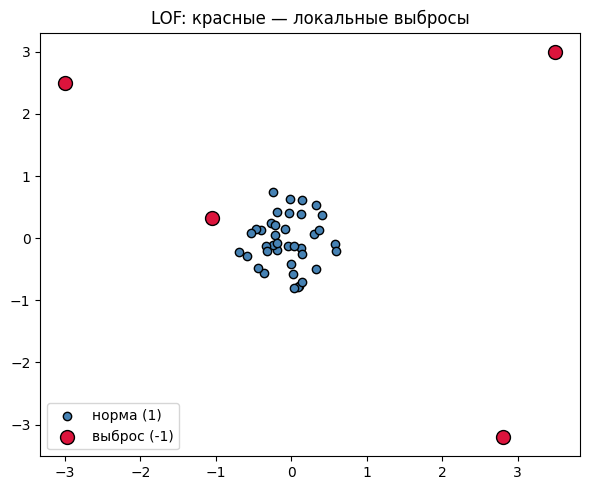

Метки (1 норма, -1 выброс): [ 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1 -1 -1]
Сколько выбросов: 4


In [125]:
# 2D-пример: кучка + 3 далёкие точки
blob = np.random.randn(40, 2) * 0.4
out = np.array([[3.5, 3.0], [-3.0, 2.5], [2.8, -3.2]])
X2 = np.vstack([blob, out])

print(X2[-6:])

lof = LocalOutlierFactor(n_neighbors=10, novelty=False)
labels_lof = lof.fit_predict(X2)  # 1 = ok, -1 = outlier
scores = -lof.negative_outlier_factor_  # чем больше, тем «аномальнее»

print(scores)

plt.figure(figsize=(6, 5))
plt.scatter(X2[labels_lof == 1, 0], X2[labels_lof == 1, 1], c="steelblue", label="норма (1)", edgecolors="k")
plt.scatter(X2[labels_lof == -1, 0], X2[labels_lof == -1, 1], c="crimson", label="выброс (-1)", edgecolors="k", s=100)
plt.title("LOF: красные — локальные выбросы")
plt.legend()
plt.tight_layout()
plt.show()

print("Метки (1 норма, -1 выброс):", labels_lof)
print("Сколько выбросов:", (labels_lof == -1).sum())



<a id="ml"></a>
## 7. Методы машинного обучения

### 7.1. Isolation Forest («изолирующий лес»)

**Идея:** случайно режем пространство признаками (как случайные деревья).  
Аномалию **легче изолировать** (она отделится за малое число разрезов).

- `predict`: **1** = норма, **-1** = выброс  
- Хорош для **многомерных** данных, часто «из коробки» работает неплохо

### 7.2. One-Class SVM

**Идея:** учимся описывать **облако нормальных** точек.  
Всё, что **вне** найденной «оболочки/границы» — аномалия.

- Параметр `nu` — примерно **ожидаемая доля** выбросов (0.1 ≈ 10%).  
- Чувствителен к масштабу → часто делают `StandardScaler`.



IsolationForest(contamination=0.1, random_state=42)
[ 1  1  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1  1  1
  1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1 -1 -1 -1]
[[-0.20986329 -0.22094877]
 [ 0.10731352 -0.89146299]
 [-0.77710168 -0.26567492]
 [-0.45690915  0.14034138]
 [-0.40978226 -0.6594076 ]
 [ 0.65754886 -0.10980087]
 [ 0.02887857 -0.66517196]
 [-0.24626953  0.04616011]
 [-0.51903443  0.16880571]
 [-0.27156524 -0.14033423]
 [-0.27204544  0.85276665]
 [-0.00755483 -0.49515806]
 [ 0.36837473 -0.57072214]
 [ 0.09243057 -0.91295107]
 [-0.59870971  0.08596742]
 [ 0.33056859  0.07415893]
 [-0.05348744 -0.14469298]
 [-0.66630884 -0.33865614]
 [-0.20861374  0.48444556]
 [ 0.15302354 -0.82187087]
 [ 0.14423986 -0.18359237]
 [-0.30586633  0.27811228]
 [ 0.46210715  0.42615473]
 [-0.37884313 -0.14844897]
 [ 0.14746813  0.44665855]
 [-0.21694828 -0.09121828]
 [-0.49895352 -0.55931011]
 [ 0.36386961  0.62299875]
 [-0.03386537  0.45962266]
 [ 0.16112528 -0.30404331]
 [ 0.1

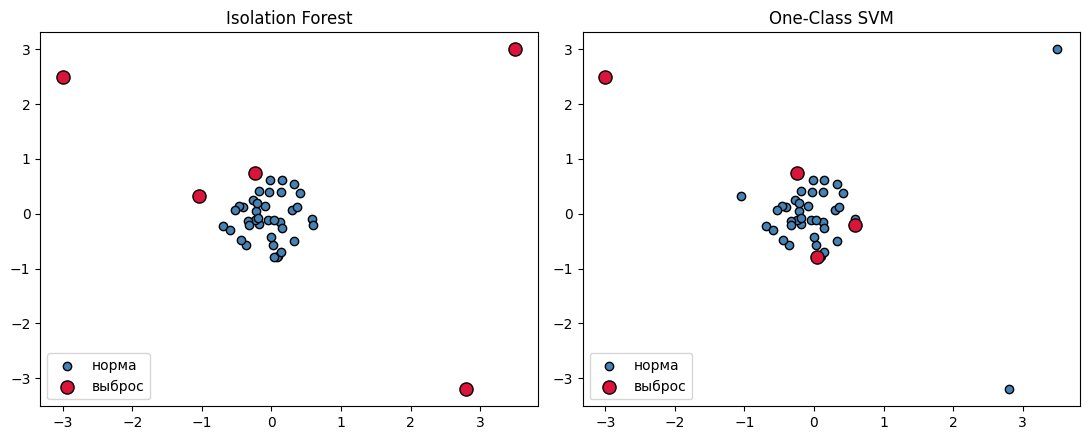

Аномальные точки (Isolation Forest):
[[-0.24068264  0.74091127]
 [-1.04789804  0.328761  ]
 [ 3.5         3.        ]
 [-3.          2.5       ]
 [ 2.8        -3.2       ]]
Аномальные точки (One-Class SVM):
[[-0.24068264  0.74091127]
 [ 0.03670431 -0.79502757]
 [ 0.59115762 -0.20730809]
 [-3.          2.5       ]]


In [126]:
# Те же 2D-данные, на которых мы уже строили LOF
# Создаём модель Isolation Forest с ожидаемой долей выбросов 10%
iso = IsolationForest(random_state=42, contamination=0.1)
print(iso)

# Обучаем модель и получаем метки: 1 — норма, -1 — выброс
labels_iso = iso.fit_predict(X2)
print(labels_iso)

# One-Class SVM лучше работает на масштабированных признаках
# Масштабируем данные, чтобы признаки были на одной шкале
X2s = StandardScaler().fit_transform(X2)
print(X2s)

# Создаём модель One-Class SVM
ocsvm = OneClassSVM(nu=0.1, kernel="rbf", gamma="scale")

# Обучаем модель и получаем метки
labels_svm = ocsvm.fit_predict(X2s)

# Создаём сетку из двух графиков: слева — Isolation Forest, справа — One-Class SVM
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Проходим по двум моделям и рисуем результат для каждой
for ax, labels, title in [
    (axes[0], labels_iso, "Isolation Forest"),
    (axes[1], labels_svm, "One-Class SVM"),
]:
    # Рисуем точки, которые модель считает нормальными
    ax.scatter(X2[labels == 1, 0], X2[labels == 1, 1], c="steelblue", edgecolors="k", label="норма")
    # Рисуем точки, которые модель считает выбросами
    ax.scatter(X2[labels == -1, 0], X2[labels == -1, 1], c="crimson", edgecolors="k", s=90, label="выброс")
    # Добавляем заголовок к каждому графику
    ax.set_title(title)
    # Добавляем легенду
    ax.legend()

# Автоматически подгоняем расстояния между подграфиками
plt.tight_layout()

# Показываем график
plt.show()

# Аномальные точки по Isolation Forest
print("Аномальные точки (Isolation Forest):")
print(X2[labels_iso == -1])

# Аномальные точки по One-Class SVM
print("Аномальные точки (One-Class SVM):")
print(X2[labels_svm == -1])

# Почему в ответе попадают точки вроде [-0.7765, 0.1316] или [0.8077, 0.3102]?
# IsolationForest с contamination=0.1 пытается выделить примерно 10% аномалий;
# One-Class SVM с nu=0.1 тоже пытается считать примерно 10% данных аномальными.
# На 43 точки это примерно 4–5 точек. Поэтому модель может выбрать:

# 3 явных дальних выброса,
# плюс 1–2 точки, которые лежат на краю “нормального” кластера.


<a id="dbscan"></a>
## 8. DBSCAN — кластеры + «шум»

**DBSCAN** — кластеризация по плотности:
- рядом много точек → **кластер**;
- точка никуда не пристроилась → метка **-1** = **шум / выброс**.

Параметры:
- `eps` — радиус «соседства»;
- `min_samples` — сколько соседей нужно, чтобы считать точку «ядром» кучи.

Плюс: не нужно заранее знать число кластеров.  
Минус: `eps` нужно подбирать; данные лучше **масштабировать**.



Кластеров: 1
Точек-шума (выбросы по DBSCAN): 4
Метки: [ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0 -1  0  0  0  0  0  0  0 -1 -1 -1]


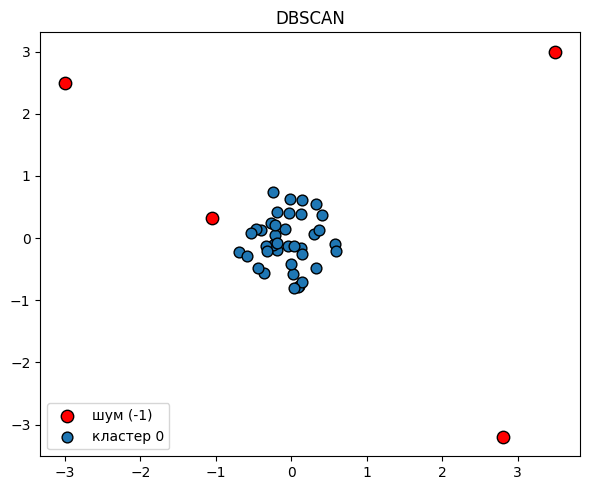

In [127]:
# Масштабируем признаки, чтобы DBSCAN корректно работал с расстояниями
X2s = StandardScaler().fit_transform(X2)

# Создаём модель DBSCAN с радиусом соседства 0.6 и минимумом 5 точек
db = DBSCAN(eps=0.6, min_samples=5)

# Обучаем модель и получаем метки: -1 — шум/выброс, остальные числа — номера кластеров
labels_db = db.fit_predict(X2s)  # -1 = шум

# Считаем число кластеров: из всех уникальных меток вычитаем 1, если есть шум
n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)

# Считаем, сколько точек было помечено как шум
n_noise = list(labels_db).count(-1)

print("Кластеров:", n_clusters)
print("Точек-шума (выбросы по DBSCAN):", n_noise)
print("Метки:", labels_db)

# Создаём новый график
plt.figure(figsize=(6, 5))

for lab in sorted(set(labels_db)):
    # Маска для точек, принадлежащих текущему кластеру
    mask = labels_db == lab
    # Если это шум, рисуем его красным цветом
    if lab == -1:
        plt.scatter(X2[mask, 0], X2[mask, 1], c="red", s=80, label="шум (-1)", edgecolors="k")
    # Иначе рисуем точки кластера
    else:
        plt.scatter(X2[mask, 0], X2[mask, 1], s=60, label=f"кластер {lab}", edgecolors="k")

plt.title("DBSCAN")
plt.legend()
plt.tight_layout()
plt.show()

<a id="practice"></a>
## 9. Практика: датасет вин (как в оригинале)

Реальные числа, один признак `proanthocyanins` — гистограмма и boxplot.  
Потом два признака и границы Isolation Forest / LOF / One-Class SVM.



In [128]:
wine = load_wine()
# признаки вин → таблица с понятными именами столбцов
X_wine = pd.DataFrame(wine.data, columns=wine.feature_names)
print("Размер:", X_wine.shape)
X_wine[["malic_acid", "ash", "proanthocyanins"]].describe().round(2)



Размер: (178, 13)


,malic_acid,ash,proanthocyanins
count,178.00,178.00,178.00
mean,2.34,2.37,1.59
std,1.12,0.27,0.57
min,0.74,1.36,0.41
25%,1.60,2.21,1.25
50%,1.87,2.36,1.56
75%,3.08,2.56,1.95
max,5.80,3.23,3.58


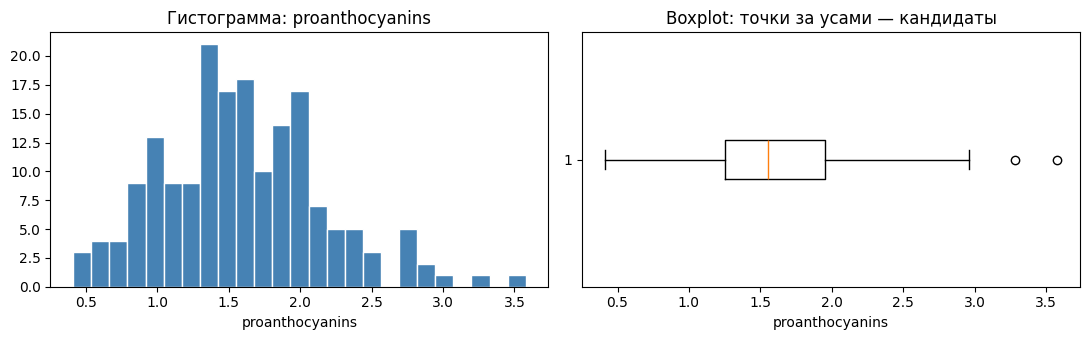

IQR-границы: [0.20, 3.00]
Кандидатов в выбросы по IQR: 2


In [129]:
col = "proanthocyanins"

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(X_wine[col], bins=25, color="steelblue", edgecolor="white")
axes[0].set_title("Гистограмма: " + col)
axes[0].set_xlabel(col)

axes[1].boxplot(X_wine[col], vert=False)  # vert=False — «лежачий» ящик
axes[1].set_title("Boxplot: точки за усами — кандидаты")
axes[1].set_xlabel(col)

plt.tight_layout()
plt.show()

# IQR: границы «ящика» ± 1.5 ширины
q1 = X_wine[col].quantile(0.25)  # 25-й процентиль
q3 = X_wine[col].quantile(0.75)  # 75-й процентиль
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
# сколько точек вышло за усы boxplot
n_out = ((X_wine[col] < low) | (X_wine[col] > high)).sum()
print(f"IQR-границы: [{low:.2f}, {high:.2f}]")
print("Кандидатов в выбросы по IQR:", int(n_out))



/var/folders/5v/0vkb__lj78l6_0j2wqd89c0r0000gn/T/ipykernel_26525/2017970037.py:24: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs.collections[0].set_label(name)
/var/folders/5v/0vkb__lj78l6_0j2wqd89c0r0000gn/T/ipykernel_26525/2017970037.py:24: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs.collections[0].set_label(name)
/var/folders/5v/0vkb__lj78l6_0j2wqd89c0r0000gn/T/ipykernel_26525/2017970037.py:24: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs.collections[0].set_label(name)


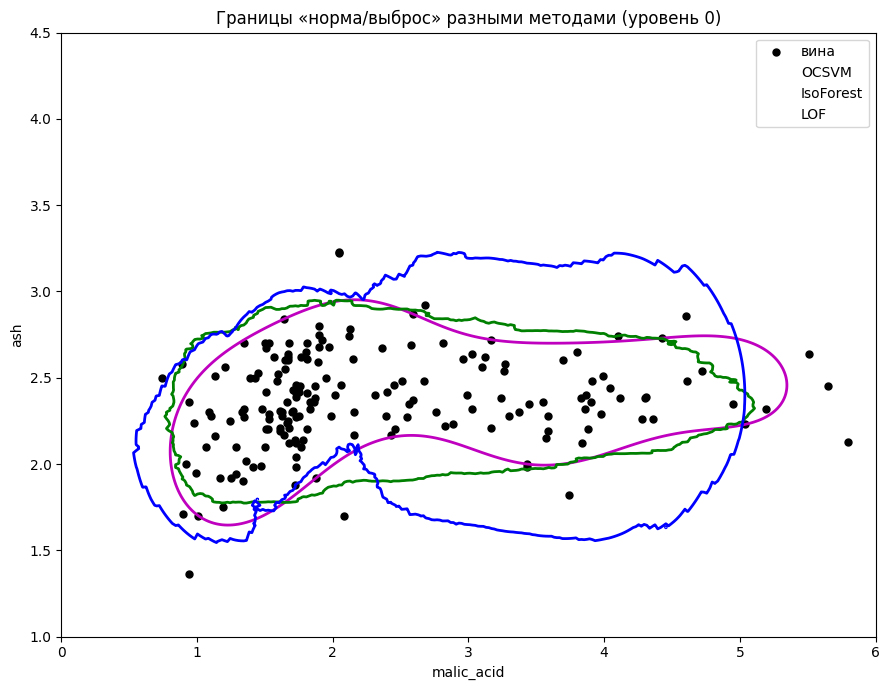

Линии — где алгоритм отделяет «свою» область от выбросов.
Методы спорят: границы разные — это нормально.


In [130]:
# Два признака: malic_acid и ash (как в скринкасте)
X1 = X_wine[["malic_acid", "ash"]].values  # numpy-матрица (n, 2)

# три детектора выбросов; nu/contamination ≈ ожидаемая доля аномалий
classifiers = {
    "OCSVM": OneClassSVM(nu=0.1),
    "IsoForest": IsolationForest(random_state=42, contamination=0.1),
    "LOF": LocalOutlierFactor(novelty=True, n_neighbors=20),  # novelty=True → есть decision_function
}
colors = ["m", "g", "b"]

# сетка точек плоскости — чтобы нарисовать границу decision_function = 0
xx, yy = np.meshgrid(np.linspace(0, 6, 300), np.linspace(1, 4.5, 300))
grid = np.c_[xx.ravel(), yy.ravel()]  # (N, 2): все пары (x, y) сетки в один массив

plt.figure(figsize=(9, 7))
plt.scatter(X1[:, 0], X1[:, 1], c="black", s=25, label="вина")

for (name, clf), color in zip(classifiers.items(), colors):
    clf.fit(X1)
    # score на сетке → картинка; level 0 ≈ граница «норма / выброс»
    Z = clf.decision_function(grid).reshape(xx.shape)
    cs = plt.contour(xx, yy, Z, levels=[0], colors=color, linewidths=2)
    cs.collections[0].set_label(name)

plt.xlabel("malic_acid")
plt.ylabel("ash")
plt.title("Границы «норма/выброс» разными методами (уровень 0)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("Линии — где алгоритм отделяет «свою» область от выбросов.")
print("Методы спорят: границы разные — это нормально.")



### Искусственные данные + One-Class SVM / Isolation Forest

Две «облака» нормальных точек + жёлтые/красные выбросы снаружи (как в оригинальном уроке).



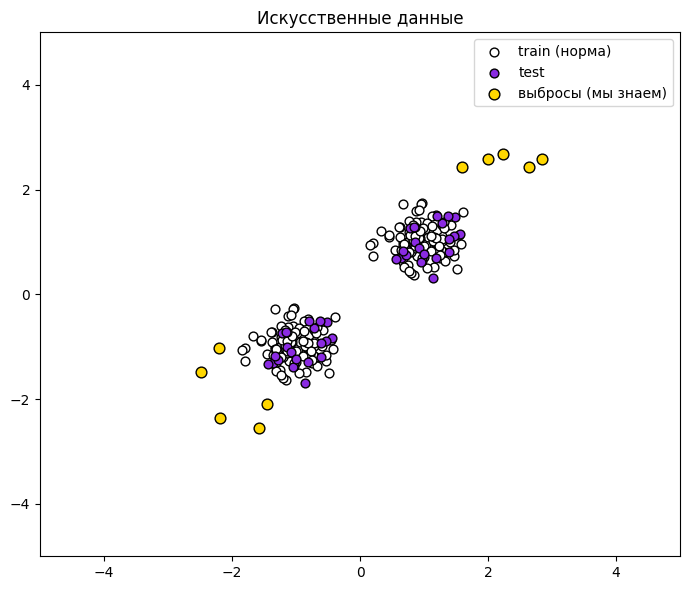

In [131]:
np.random.seed(9)

# два кластера «нормы»: облако шума сдвинули в (+1,+1) и в (−1,−1)
X = 0.3 * np.random.randn(100, 2)
X_train = np.r_[X + 1, X - 1]  # склеить два облака по вертикали (строкам)

X = 0.3 * np.random.randn(20, 2)
X_test = np.r_[X + 1, X - 1]

# искусственные выбросы: случайные точки в «пустых» углах
X_out = np.r_[
    np.random.uniform(-3, -1, size=(5, 2)),
    np.random.uniform(1, 3, size=(5, 2)),
]

plt.figure(figsize=(7, 6))
plt.scatter(X_train[:, 0], X_train[:, 1], c="white", edgecolors="k", s=40, label="train (норма)")
plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet", edgecolors="k", s=40, label="test")
plt.scatter(X_out[:, 0], X_out[:, 1], c="gold", edgecolors="k", s=60, label="выбросы (мы знаем)")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.legend()
plt.title("Искусственные данные")
plt.tight_layout()
plt.show()



In [132]:
# учим One-Class SVM (в т.ч. на выбросах — как демо границ)
clf_svm = OneClassSVM(nu=0.1)  # nu ≈ доля точек, которые можно счесть выбросами
clf_svm.fit(np.r_[X_train, X_out])  # обучение на train + известных outliers

print("predict train (фрагмент):", clf_svm.predict(X_train)[:20])
print("  1 = норма, -1 = выброс")
# сколько точек модель пометила как -1
print("Выбросов среди train по модели:", int((clf_svm.predict(X_train) == -1).sum()))
print("Выбросов среди «известных outliers»:", int((clf_svm.predict(X_out) == -1).sum()), "из", len(X_out))



predict train (фрагмент): [ 1  1  1  1  1  1  1  1 -1  1  1  1  1  1  1  1  1  1  1  1]
  1 = норма, -1 = выброс
Выбросов среди train по модели: 9
Выбросов среди «известных outliers»: 10 из 10


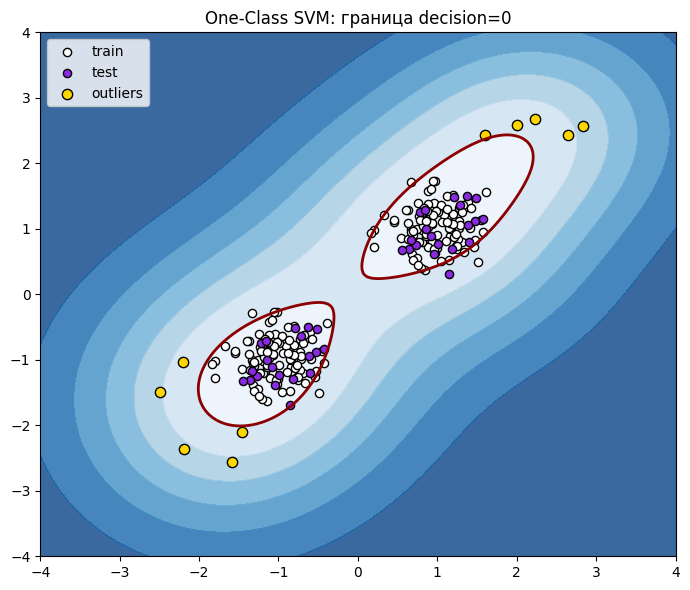

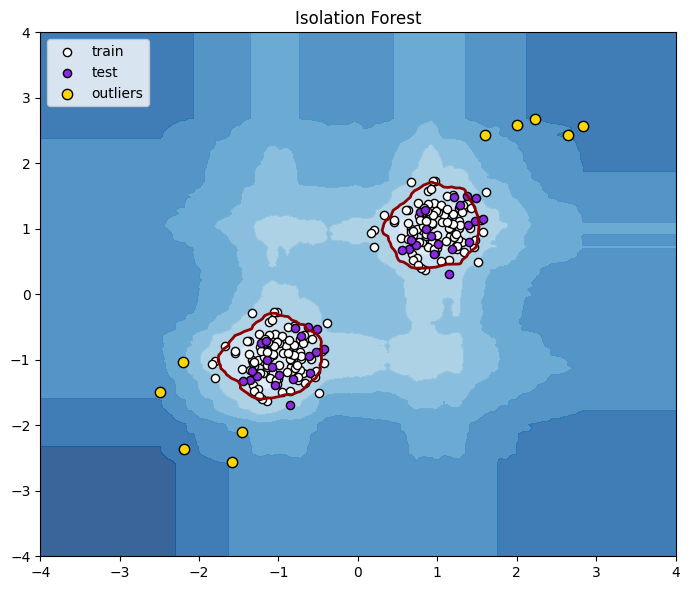

In [133]:
def plot_boundary(clf, title, X_train, X_test, X_out):
    # координатная сетка для фона «score аномальности»
    xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-5, 5, 200))
    # decision_function: >0 ближе к норме, граница часто около 0
    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, cmap=plt.cm.Blues_r, alpha=0.8)  # заливка score
    plt.contour(xx, yy, Z, levels=[0], colors="darkred", linewidths=2)  # линия границы
    plt.scatter(X_train[:, 0], X_train[:, 1], c="white", edgecolors="k", s=35, label="train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c="blueviolet", edgecolors="k", s=35, label="test")
    plt.scatter(X_out[:, 0], X_out[:, 1], c="gold", edgecolors="k", s=55, label="outliers")
    plt.xlim(-4, 4)
    plt.ylim(-4, 4)
    plt.title(title)
    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()


plot_boundary(clf_svm, "One-Class SVM: граница decision=0", X_train, X_test, X_out)

clf_iso = IsolationForest(random_state=42)
clf_iso.fit(np.r_[X_train, X_out])
plot_boundary(clf_iso, "Isolation Forest", X_train, X_test, X_out)



Кластеров: 2
Шума (-1): 7


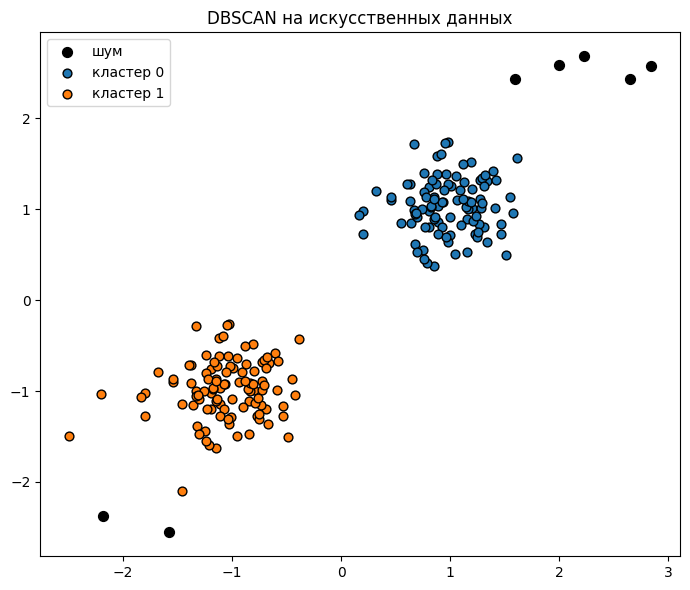

In [134]:
# DBSCAN на train + outliers
# масштабируем: eps в DBSCAN — расстояние, чувствителен к шкале
X_all = StandardScaler().fit_transform(np.r_[X_train, X_out])
db = DBSCAN(eps=0.5, min_samples=5).fit(X_all)  # eps — радиус соседей
labels = db.labels_  # номер кластера; -1 = шум (выброс)

# -1 не считается отдельным кластером
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print("Кластеров:", n_clusters)
print("Шума (-1):", n_noise)

plt.figure(figsize=(7, 6))
for lab in sorted(set(labels)):
    mask = labels == lab
    pts = np.r_[X_train, X_out][mask]  # исходные (не scaled) координаты для рисунка
    if lab == -1:
        plt.scatter(pts[:, 0], pts[:, 1], c="black", s=50, label="шум", edgecolors="k")
    else:
        plt.scatter(pts[:, 0], pts[:, 1], s=40, label=f"кластер {lab}", edgecolors="k")
plt.title("DBSCAN на искусственных данных")
plt.legend()
plt.tight_layout()
plt.show()



<a id="итог"></a>
## 10. Итог

1. **Выброс** — точка «не из общей картины». Бывает ошибкой, шумом или **полезной аномалией**.
2. **Сначала смотри** (гистограмма, boxplot), потом считай (IQR, Z-score), потом усложняй (LOF, Isolation Forest, SVM, DBSCAN).
3. Методы **спорят** — нет единственно верной границы; сверяй с предметным смыслом.
4. **Не всегда удаляй**: иногда выброс — самое важное (мошенничество, поломка).
5. Для моделей, чувствительных к масштабу, перед метрическими/SVM методами делай **StandardScaler**.

### Шпаргалка «что попробовать»

| Ситуация | Старт |
|----------|--------|
| Один числовой столбец | boxplot + IQR |
| Нужна простая многомерность | Isolation Forest |
| Важна локальная плотность | LOF |
| Есть явные «кучки» + шум | DBSCAN |
| Хочешь «оболочку нормы» | One-Class SVM (+ scaling) |

### Что делать с найденным выбросом
- **Исправить** (если опечатка),
- **удалить** (если мусор и мало точек),
- **оставить + устойчивая модель** (деревья часто терпимее),
- **отдельный флаг** `is_outlier` — иногда сам факт аномалии полезен как признак.

